In [1]:
import numpy as np
a=np.arange(0, 10, 0.5)
print(len(a),a) #0~10까지 0.5 간격으로 값 생성
data = np.sin(a)
print(data)
print(len(data))

20 [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]
[ 0.          0.47942554  0.84147098  0.99749499  0.90929743  0.59847214
  0.14112001 -0.35078323 -0.7568025  -0.97753012 -0.95892427 -0.70554033
 -0.2794155   0.21511999  0.6569866   0.93799998  0.98935825  0.79848711
  0.41211849 -0.07515112]
20


In [3]:
#################################
#data=[1,2,3,4,5,6,7,8,9,10]
timestep = 3 # t-3, t-2, t-1 데이터를 이용하여 t 시점의 값을 예측
X, y = [], []
for i in range(timestep, len(data)):
    X.append(np.array([data[i-j] for j in range(timestep, 0, -1)]))
    y.append(data[i])

print(X)

[array([0.        , 0.47942554, 0.84147098]), array([0.47942554, 0.84147098, 0.99749499]), array([0.84147098, 0.99749499, 0.90929743]), array([0.99749499, 0.90929743, 0.59847214]), array([0.90929743, 0.59847214, 0.14112001]), array([ 0.59847214,  0.14112001, -0.35078323]), array([ 0.14112001, -0.35078323, -0.7568025 ]), array([-0.35078323, -0.7568025 , -0.97753012]), array([-0.7568025 , -0.97753012, -0.95892427]), array([-0.97753012, -0.95892427, -0.70554033]), array([-0.95892427, -0.70554033, -0.2794155 ]), array([-0.70554033, -0.2794155 ,  0.21511999]), array([-0.2794155 ,  0.21511999,  0.6569866 ]), array([0.21511999, 0.6569866 , 0.93799998]), array([0.6569866 , 0.93799998, 0.98935825]), array([0.93799998, 0.98935825, 0.79848711]), array([0.98935825, 0.79848711, 0.41211849])]


In [4]:
print(y)

[np.float64(0.9974949866040544), np.float64(0.9092974268256817), np.float64(0.5984721441039564), np.float64(0.1411200080598672), np.float64(-0.35078322768961984), np.float64(-0.7568024953079282), np.float64(-0.977530117665097), np.float64(-0.9589242746631385), np.float64(-0.7055403255703919), np.float64(-0.27941549819892586), np.float64(0.21511998808781552), np.float64(0.6569865987187891), np.float64(0.9379999767747389), np.float64(0.9893582466233818), np.float64(0.7984871126234903), np.float64(0.4121184852417566), np.float64(-0.0751511204618093)]


In [5]:
#################################
#신경망에 입력하기 위해 차원 변경
X, y = np.array(X).reshape(len(X), 3, 1), np.array(y).reshape(len(y), 1)
print(X.shape)
print(y.shape)

(17, 3, 1)
(17, 1)


In [6]:
#################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Input, Dense
np.random.seed(0)
model=Sequential()
model.add(Input(shape=(3, 1)))  # timestep=3, feature=1
model.add(SimpleRNN(units=10)) # 출력노드수
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='linear')) #activation='linear' 기본값으로 생략가능
model.compile(loss='mse', optimizer='sgd')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
#################################
history = model.fit(X, y, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - loss: 0.5423
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5044
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4744
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.4495
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4292
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4124
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3968
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3827
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3696
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3575
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3461
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3353
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3256
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3163
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3070
Epo

In [8]:
#################################
model.evaluate(X,y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 5.6802e-04


0.0005680241738446057

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


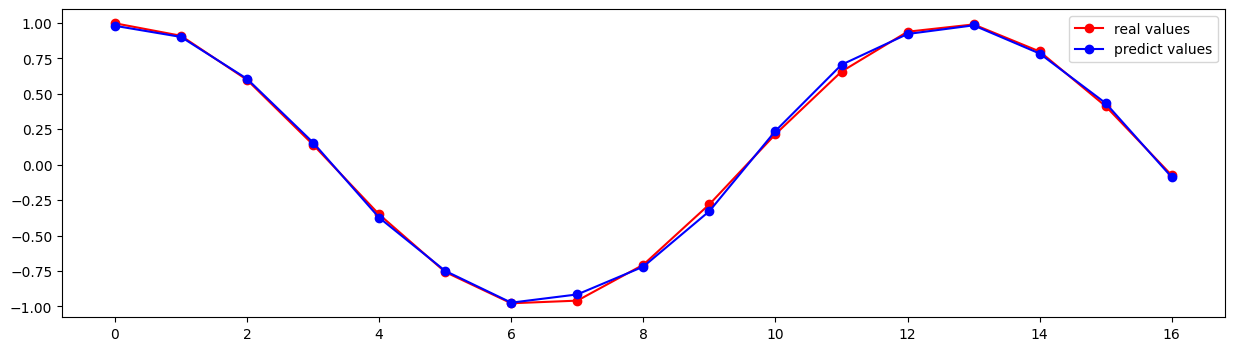

In [9]:
#################################
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 4))
plt.plot(data[3:], 'ro-', label='real values') # 실제값
plt.plot(model.predict(X), 'bo-', label='predict values') #예측값
plt.legend()
plt.show()
